# Seminar 01: Metrics for Evaluating Generated Images

1. Inception Score (IS)
2. Fréchet Inception Distance (FID)
3. LPIPS (Learned Perceptual Image Patch Similarity)

## Inception Score (IS)

[Original paper](https://arxiv.org/abs/1606.03498)

- **Purpose:** Evaluates image quality and diversity from a generative model using a pretrained classifier (commonly Inception v3).

- **Procedure:**
  1. **Prediction:** For each generated image $x$, obtain the class distribution $p(y \mid x)$.
  2. **Quality Check:** A sharp $p(y \mid x)$ (low entropy) implies the image is confidently classified.
  3. **Diversity Check:** Compute the marginal distribution:
     $$
     p(y) = \frac{1}{N} \sum_{i=1}^{N} p(y \mid x_i)
     $$
     A uniform $p(y)$ suggests diverse outputs.
  4. **Score Calculation:** Combine quality and diversity using the KL divergence:
     $$
     \text{IS} = \exp\!\left(\frac{1}{N}\sum_{i=1}^{N} \text{KL}\Big(p(y \mid x_i) \,\|\, p(y)\Big)\right)
     $$

- **Notes:**
  - Higher IS values indicate better quality and more diversity.
  - The score depends on the chosen classifier and may be affected by domain mismatches.


![image](https://miro.medium.com/max/2976/1*X29oOi1Tzch2j6MuG9XS1Q.png)
![image](https://miro.medium.com/max/2812/1*t8lE_W4UKQ8jKgzxCAbHTA.png)

### How it works
We compare each samples classes with averaged (marginal) one. If each sample's distribution differs from common (marginal) one, then it differs from others.

![image](https://miro.medium.com/max/3472/1*hPEJY3MkOZyKFA6yEqzuyg.png)

Here KL divergence is used to calculate the distance

## Fréchet Inception Distance (FID)

**Idea:** Compare the distributions of real and generated samples in a feature space.

**Algorithm:**
1. **Feature Extraction:** Extract embeddings from intermediate layers of a pretrained network (often Inception v3).
2. **Distribution Modeling:** Assume that these embeddings for real and generated images follow Gaussian distributions:
   - Real images: $\mathcal{N}(\mu_1, \Sigma_1)$
   - Generated images: $\mathcal{N}(\mu_2, \Sigma_2)$
3. **Distance Calculation:** Compute the Fréchet Distance between these distributions:
   $$
   \text{FID} = \|\mu_1 - \mu_2\|^2 + \operatorname{Tr}\Big(\Sigma_1 + \Sigma_2 - 2(\Sigma_1\Sigma_2)^{1/2}\Big)
   $$
   A lower FID means that the generated images are closer to real images in the feature space.

## Metrics summary

![](https://miro.medium.com/max/875/0*GHvXKp6DQPAHGdqH)

### Comparison

|                            Metric |                                 IS                                 | FID                                                            | LPIPS                                                    |
|--------------------------------------:|:------------------------------------------------------------------:|----------------------------------------------------------------|----------------------------------------------------------|
| **Aim**                               | Measure the *diversity* and *confidence* in generated images       | Measure the *closeness* of generated images to real images       | Quantify *perceptual similarity* between pairs of images |
| **Which distributions are compared?** | Discrete predicted class distributions (sample vs. marginal)         | Continuous Gaussian approximations (real vs. generated)          | Feature space differences between image patches          |
| **Which data is used?**               | Generated images only                                                | Both real and generated images                                  | Typically image pairs (generated vs. reference images)   |
| **Which distance is used?**           | Kullback–Leibler (KL) divergence                                     | Fréchet distance                                                | Learned weighted L2 distances in deep feature space      |


## LPIPS (Learned Perceptual Image Patch Similarity)

**LPIPS Formula:**
$$
d_{LPIPS}(x,y)=\sum_l\frac{1}{H_lW_l}\sum_{i,j}\Big\|w_l \cdot\Big(\hat{x}^l_{ij}-\hat{y}^l_{ij}\Big)\Big\|_2^2
$$
- **Explanation:**  
  - $\hat{x}^l_{ij}$ and $\hat{y}^l_{ij}$: Normalized feature vectors at layer $l$ and spatial location $(i,j)$ for images $x$ and $y$, respectively.
  - $w_l$: Learned weights for channel-wise comparison at layer $l$.
  - $H_l$ and $W_l$: Height and width of the feature maps at layer $l$.

This formulation captures the perceptual differences between images, aligning more closely with human visual assessments than simple pixel-wise errors.

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from tqdm.auto import tqdm

%matplotlib inline

In [ ]:
!pip install lpips

In [1]:
dataset = torchvision.datasets.FashionMNIST('../data/fashion_mnist', download=True)

/Users/kgb/opt/miniforge3/envs/py311_dgm/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/kgb/opt/miniforge3/envs/py311_dgm/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <CFED5F8E-EC3F-36FD-AAA3-2C6C7F8D3DD9> /Users/kgb/opt/miniforge3/envs/py311_dgm/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <8E6D6BF5-9658-33B9-9D3C-DF587B2F99E7> /Users/kgb/opt/miniforge3/envs/py311_dgm/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


100%|██████████| 26421880/26421880 [00:01<00:00, 15593512.97it/s]


Extracting ../data/fashion_mnist/FashionMNIST/raw/train-images-idx3-ubyte.gz to ../data/fashion_mnist/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 279821.26it/s]


Extracting ../data/fashion_mnist/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ../data/fashion_mnist/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 3469795.67it/s]


Extracting ../data/fashion_mnist/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ../data/fashion_mnist/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 11460868.89it/s]

Extracting ../data/fashion_mnist/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/fashion_mnist/FashionMNIST/raw



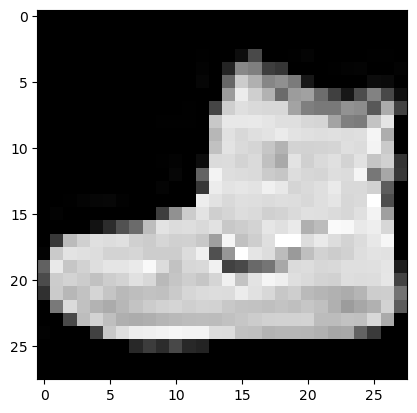

In [17]:
original_img_idx = 0
original_img, original_label = dataset[original_img_idx]
plt.imshow(original_img, cmap='gray')
plt.show()

### Task
Find closest image to the above one

In [ ]:
import lpips

loss_fn = lpips.LPIPS(net='alex')

def img2tensor(img):
    """
    Convert a PIL image to a Torch tensor.
    Resize to 512x512.
    """
    return torch.from_numpy(np.array(img.resize((512,512))))

np.random.seed(10)
img_indices = np.random.choice(np.arange(len(dataset)), 1000) # random images to be compared
img_indices = [idx for idx in img_indices if idx != original_img_idx]

distances, labels = [], []

# Calculate LPIPS distances
for idx in tqdm(img_indices, desc="Computing LPIPS distances"):
    img, label = dataset[idx]
    labels.append(label)
    
    original_tensor = img2tensor(original_img)
    curr_tensor = img2tensor(img)
    # Compute the LPIPS distance
    dist = loss_fn(original_tensor, curr_tensor)
    distances.append(dist.detach().cpu().squeeze().item())

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /Users/kgb/opt/miniforge3/envs/py311_dgm/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth


Computing LPIPS distances:   0%|          | 0/1000 [00:00<?, ?it/s]

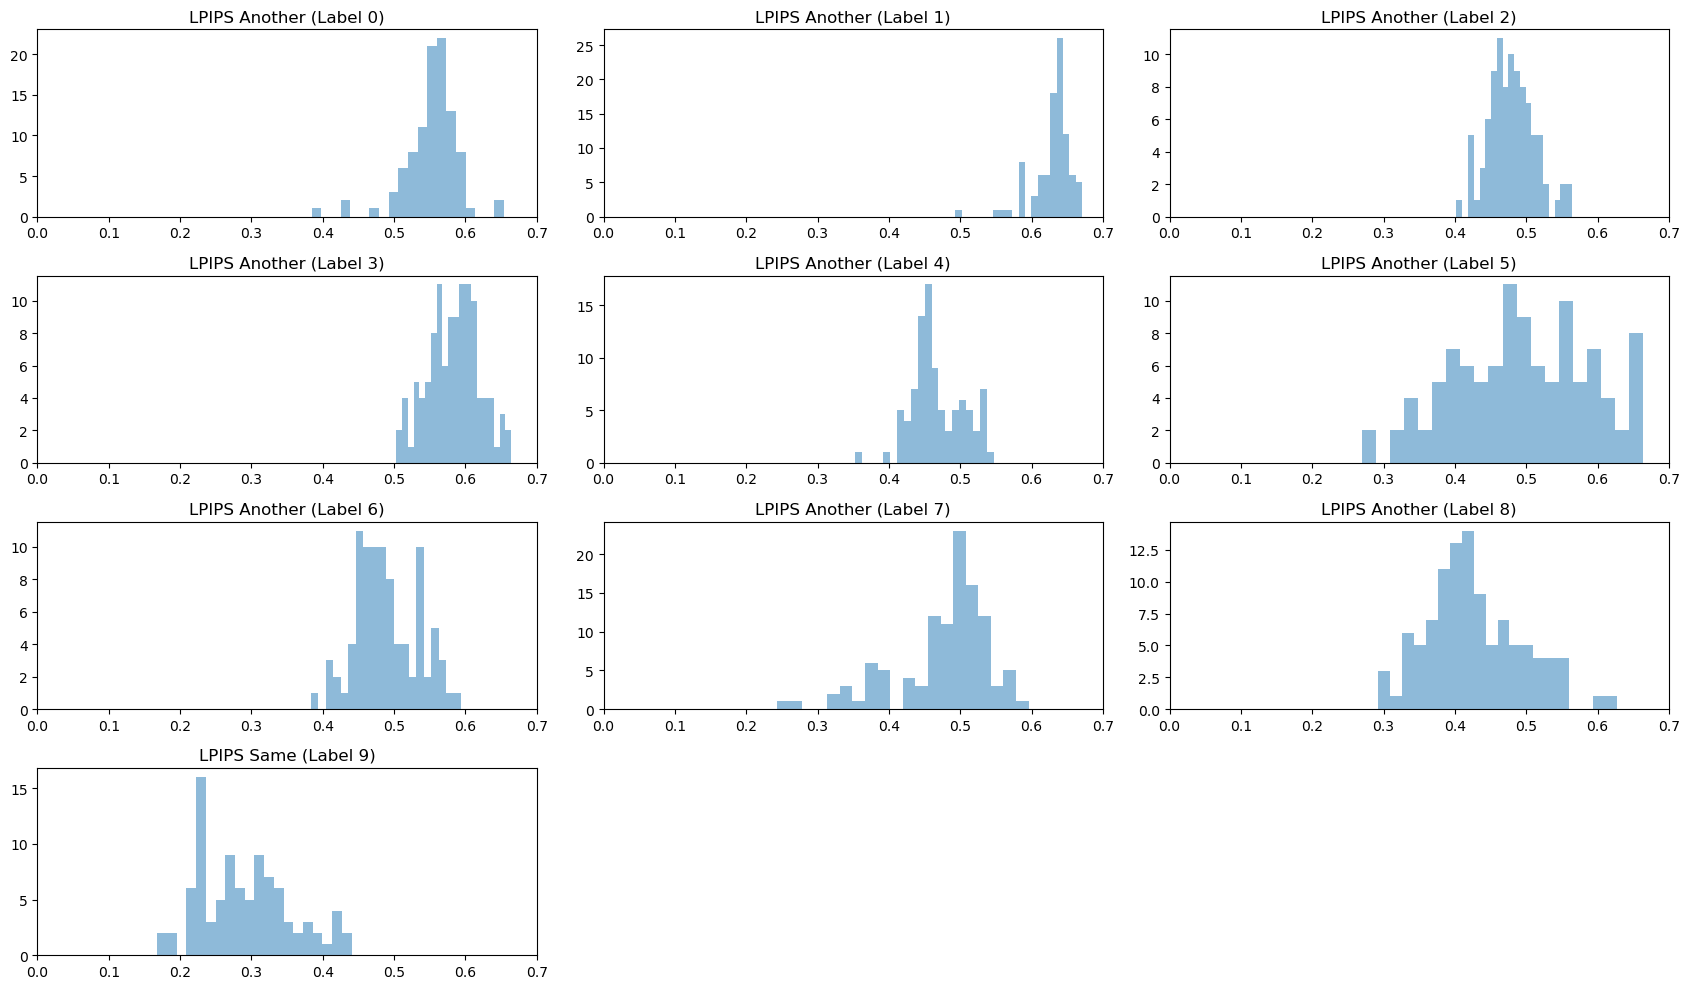

In [14]:
# Plot histograms per class
plt.figure(figsize=(17,10))
n_classes = 10
for label in range(n_classes):
    plt.subplot(4,3,label+1)
    same_class = label == original_label
    plt.title(f'LPIPS {"Same" if same_class else "Another"} (Label {label})')
    plt.xlim((0.,0.7))
    plt.hist(np.array(distances)[np.array(labels)==label], bins=20, alpha=0.5)
plt.tight_layout()
plt.show()

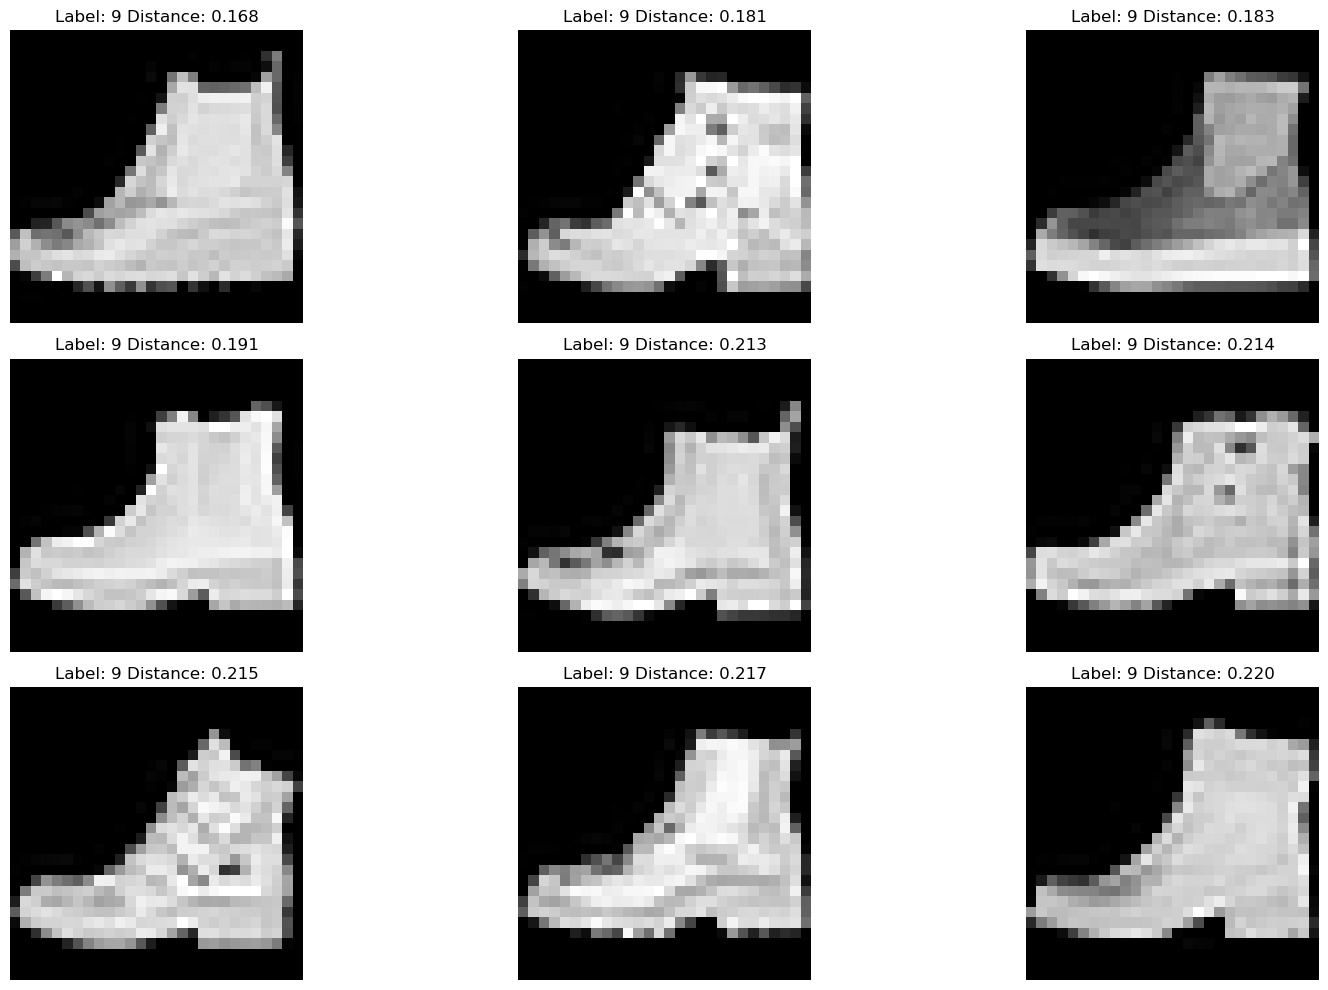

In [15]:
# Find and display the 9 closest images
plt.figure(figsize=(17,10))
closest_img_cnt = 9
sorted_indices = np.argsort(distances)
closest_img_indices = np.array(img_indices)[sorted_indices][:closest_img_cnt]
closest_distances = np.array(distances)[sorted_indices][:closest_img_cnt]
closest_labels = np.array(labels)[sorted_indices][:closest_img_cnt]

for ax_idx, (img_idx, distance, label) in enumerate(zip(closest_img_indices, closest_distances, closest_labels)):
    img, _ = dataset[img_idx]
    plt.subplot(3,3,ax_idx+1)
    plt.title(f'Label: {label} Distance: {distance:.3f}')
    plt.imshow(np.array(img), cmap='gray')
    plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# Hidden tests
assert(min(distances) < 0.2), "Minimum distance is not less than 0.2."
assert((np.array(closest_labels) == original_label).mean() > 0.9), "Less than 90% of the closest images have the same label as the original."